
- Detect outliers in Amount
- Visualize outliers using Plotly
- Remove outliers using Z-score
- Assess impact on Average Revenue

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px

from scipy.stats import zscore


In [2]:
df = pd.read_csv("../data/processed/amazon_sales_sql.csv",header=None)

df.columns=[

"idx",
"order_id",
"order_date",
"status",
"fulfilment",
"sales_channel",
"ship_service_level",
"style",
"sku",
"category",
"size",
"asin",
"courier_status",
"qty",
"currency",
"amount",
"ship_city",
"ship_state",
"ship_postal_code",
"ship_country",
"promotion_ids",
"b2b",
"fulfilled_by",
"unnamed_22"

]

C:\Users\SVS\AppData\Local\Temp\ipykernel_20428\789008179.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/amazon_sales_sql.csv",header=None)


In [3]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [4]:
df[["amount"]].describe()

,amount
count,128975.000000
mean,645.928694
std,272.778829
min,0.000000
25%,459.000000
50%,605.000000
75%,771.000000
max,5584.000000


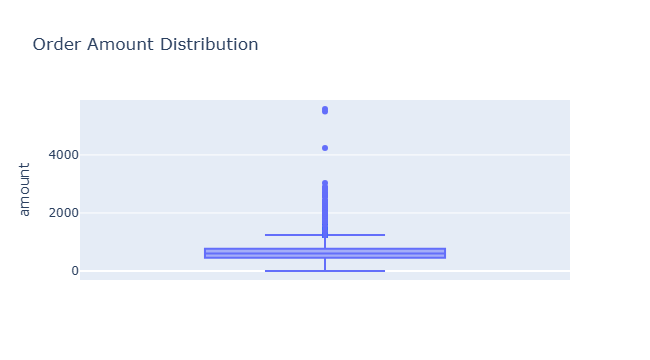

In [5]:
## plotly box plot 
fig = px.box(df,y="amount",title="Order Amount Distribution")
fig.show()

In [6]:
## z score 
df["z_score"] = zscore(df["amount"].fillna(df["amount"].mean()))

In [7]:
## identify outliers 
outliers = df[np.abs(df["z_score"]) > 3]
print("Total Outliers:", len(outliers))
outliers.head()

Total Outliers: 946


,idx,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,...,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed_22,z_score
265,265,171-6655820-6440356,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0008,J0008-SKD-XXL,Set,...,2130.00,MUMBAI,Maharashtra,400101.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,5.440587
324,324,407-5096970-7475550,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0010,J0010-LCD-L,Set,...,1902.86,HARDOI,Uttar Pradesh,241001.0,IN,NaN,False,Easy Ship,NaN,4.607895
349,349,171-3537751-4007556,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET436,SET436-KR-NP-XXXL,Set,...,1999.00,Nellore,Andhra Pradesh,524314.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,4.960343
416,416,404-0532727-2082745,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0225,J0225-SKD-XXL,Set,...,1499.00,Hyderabad,Telangana,500008.0,IN,NaN,False,NaN,NaN,3.127349
647,647,171-6153595-4758722,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-S,Set,...,2224.00,VASAI VIRAR,Maharashtra,401209.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN,5.785190


In [8]:
## remove outliers 
clean_df = df[np.abs(df["z_score"]) <= 3]

In [9]:
## compare dataset 
print("Original Dataset :", len(df))
print("After Removing Outliers :", len(clean_df))

Original Dataset : 128975
After Removing Outliers : 128029


In [10]:
## revenue comprision 
original_avg = df["amount"].mean()
clean_avg = clean_df["amount"].mean()
print("Average Revenue Before :", round(original_avg,2))
print("Average Revenue After :", round(clean_avg,2))

Average Revenue Before : 645.93
Average Revenue After : 638.74


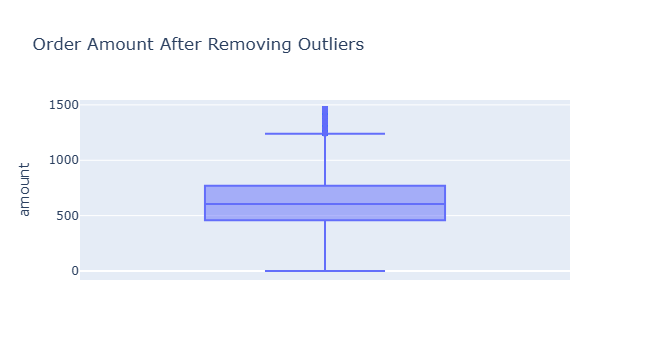

In [11]:
## compare box plots
fig = px.box(
    clean_df,
    y="amount",
    title="Order Amount After Removing Outliers"
)
fig.show()

In [12]:
## save the dataset 
clean_df.to_csv(
    "../data/processed/amazon_sales_without_outliers.csv",
    index=False
)
print("Dataset Saved Successfully")

Dataset Saved Successfully
